# Predictive Analytics Using Historical Sales Data
### Sales forecasting with regression and time-series models

**Goal:** forecast the next 30 days of sales from historical daily data.

**Pipeline:** load & clean -> explore trends -> build features -> compare baselines, regression and time-series models -> evaluate on a realistic 30-day-ahead backtest -> forecast with an uncertainty band.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# statsmodels is used for the classical time-series models (pre-installed in Colab)
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels not found - run `pip install statsmodels` to include Holt-Winters and SARIMA.")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
HORIZON = 30          # forecast length in days

## 2. Load the data

In [2]:
try:
    df = pd.read_csv("dataset.csv")
except FileNotFoundError:
    from google.colab import files      # only needed the first time in Colab
    files.upload()
    df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Saving dataset.csv to dataset.csv
Shape: (1080, 4)


,Time Date,Product,Store,Value
0,1012018,2667437,QLD_CW_ST0203,2926.000
1,2012018,2667437,QLD_CW_ST0203,2687.531
2,3012018,2667437,QLD_CW_ST0203,2793.000
3,4012018,2667437,QLD_CW_ST0203,2394.000
4,5012018,2667437,QLD_CW_ST0203,2660.000


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time Date  1080 non-null   int64  
 1   Product    1080 non-null   int64  
 2   Store      1080 non-null   object 
 3   Value      1080 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.9+ KB


,Time Date,Product,Value
count,1.080000e+03,1080.0,1080.000000
mean,1.567207e+07,2667437.0,4048.117478
std,8.791548e+06,0.0,1439.945783
min,1.012018e+06,2667437.0,2042.813500
25%,8.069518e+06,2667437.0,2632.498599
50%,1.556702e+07,2667437.0,4256.000000
75%,2.308452e+07,2667437.0,5288.248910
max,3.112202e+07,2667437.0,8147.739600


## 3. Clean and preprocess

Dates are stored as integers such as `1012018` (1 Jan 2018) with the leading zero dropped, so they are zero-padded to 8 digits (`ddmmyyyy`) before parsing. The series is then checked for duplicates and for **missing calendar days**, because lag features assume one row per day.

In [4]:
print("Missing values:\n", df.isnull().sum(), sep="")
print("\nDuplicate rows:", df.duplicated().sum())
print("Products:", df["Product"].nunique(), "| Stores:", df["Store"].nunique())

Missing values:
Time Date    0
Product      0
Store        0
Value        0
dtype: int64

Duplicate rows: 0
Products: 1 | Stores: 1


In [5]:
df = df.drop_duplicates().copy()
df["Date"] = pd.to_datetime(df["Time Date"].astype(str).str.zfill(8), format="%d%m%Y")

# one product and one store, so a single daily series (mean guards against repeated dates)
sales = df.groupby("Date")["Value"].mean().sort_index()

full_range = pd.date_range(sales.index.min(), sales.index.max(), freq="D")
missing_days = full_range.difference(sales.index)
print("Date range :", sales.index.min().date(), "to", sales.index.max().date())
print("Rows       :", len(sales), "| expected days:", len(full_range))
print("Missing days:", list(missing_days.date))

# fill gaps by linear interpolation so the series is continuous
sales = sales.reindex(full_range).interpolate()
sales.index.name = "Date"
print("Series length after filling gaps:", len(sales))

Date range : 2018-01-01 to 2020-12-16
Rows       : 1080 | expected days: 1081
Missing days: [datetime.date(2020, 2, 29)]
Series length after filling gaps: 1081


In [6]:
# outlier check (IQR rule) - kept in the data, but worth knowing about
q1, q3 = sales.quantile([0.25, 0.75])
iqr = q3 - q1
outliers = sales[(sales < q1 - 1.5 * iqr) | (sales > q3 + 1.5 * iqr)]
print(f"Values outside the IQR fences: {len(outliers)} of {len(sales)}")

Values outside the IQR fences: 0 of 1081


## 4. Exploratory analysis

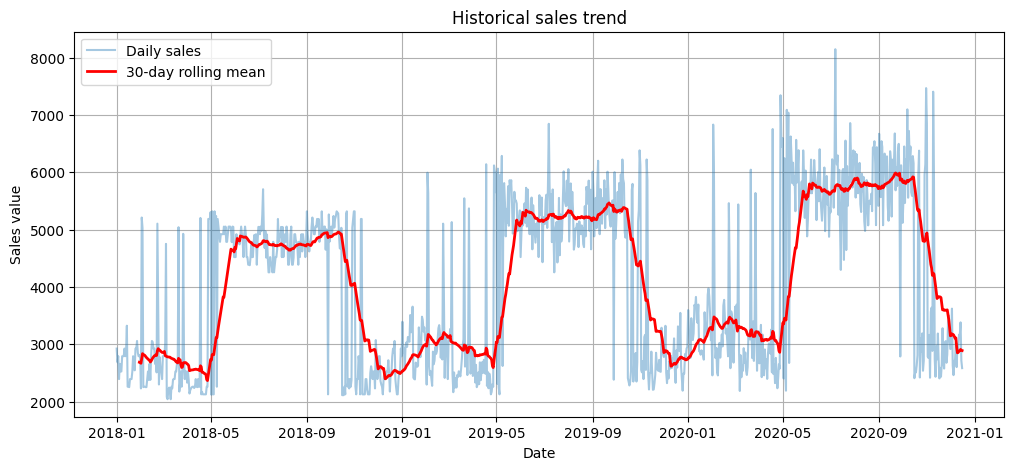

In [7]:
fig, ax = plt.subplots()
ax.plot(sales.index, sales.values, alpha=0.4, label="Daily sales")
ax.plot(sales.rolling(30).mean(), color="red", lw=2, label="30-day rolling mean")
ax.set_title("Historical sales trend"); ax.set_xlabel("Date"); ax.set_ylabel("Sales value")
ax.legend(); plt.show()

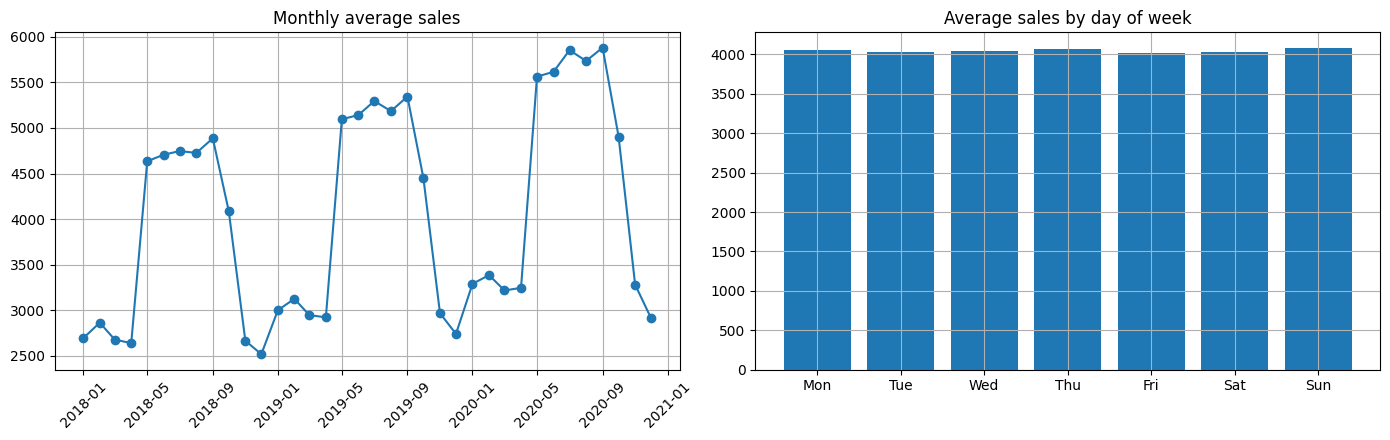

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

monthly = sales.resample("MS").mean()
axes[0].plot(monthly.index, monthly.values, marker="o")
axes[0].set_title("Monthly average sales"); axes[0].tick_params(axis="x", rotation=45)

dow = sales.groupby(sales.index.dayofweek).mean()
axes[1].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow.values)
axes[1].set_title("Average sales by day of week")
plt.tight_layout(); plt.show()

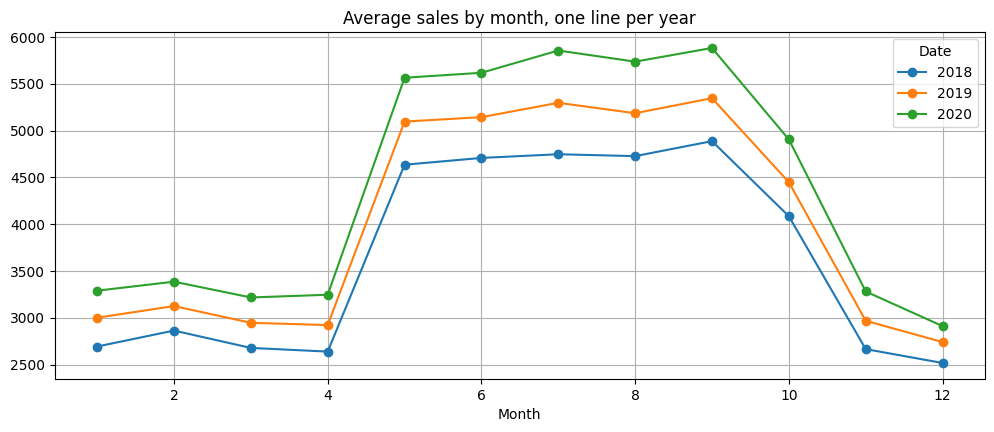

In [9]:
# same calendar month across years - is there yearly seasonality?
pivot = sales.groupby([sales.index.year, sales.index.month]).mean().unstack(0)
pivot.plot(marker="o", figsize=(12, 4.5), title="Average sales by month, one line per year")
plt.xlabel("Month"); plt.show()

## 5. Feature engineering

Features: calendar fields plus **lags** and **rolling means** of past sales. Rolling means are computed on the series shifted by one day, so a row never sees its own target. `Year` is deliberately **not** used: tree models cannot extrapolate to a year they have not seen.

In [10]:
FEATURES = ["DayOfWeek", "Month", "Day", "DayOfYear", "WeekOfYear", "IsMonthEnd",
            "Lag_1", "Lag_7", "Lag_14", "Lag_30", "Roll_7", "Roll_30"]

def make_features(s):
    """Feature table for every day of series s (used for training)."""
    d = pd.DataFrame({"Value": s})
    d["DayOfWeek"]  = d.index.dayofweek
    d["Month"]      = d.index.month
    d["Day"]        = d.index.day
    d["DayOfYear"]  = d.index.dayofyear
    d["WeekOfYear"] = d.index.isocalendar().week.astype(int)
    d["IsMonthEnd"] = d.index.is_month_end.astype(int)
    for lag in (1, 7, 14, 30):
        d[f"Lag_{lag}"] = d["Value"].shift(lag)
    d["Roll_7"]  = d["Value"].shift(1).rolling(7).mean()
    d["Roll_30"] = d["Value"].shift(1).rolling(30).mean()
    return d

def row_features(hist, date):
    """Features for ONE future day, computed from history that ends the day before (used when forecasting)."""
    v = hist.values
    return {"DayOfWeek": date.dayofweek, "Month": date.month, "Day": date.day,
            "DayOfYear": date.dayofyear, "WeekOfYear": int(date.isocalendar()[1]),
            "IsMonthEnd": int(date.is_month_end),
            "Lag_1": v[-1], "Lag_7": v[-7], "Lag_14": v[-14], "Lag_30": v[-30],
            "Roll_7": v[-7:].mean(), "Roll_30": v[-30:].mean()}

feats = make_features(sales).dropna()
print("Rows available for modelling:", len(feats))

# sanity check: the training-time and forecast-time feature code must agree
t = feats.index[100]
a = feats.loc[t, FEATURES].astype(float).values
b = pd.Series(row_features(sales.loc[:t - pd.Timedelta(days=1)], t))[FEATURES].astype(float).values
assert np.allclose(a, b), "feature mismatch between make_features and row_features"
print("Feature consistency check passed")
feats.head()

Rows available for modelling: 1051
Feature consistency check passed


,Value,DayOfWeek,Month,Day,DayOfYear,WeekOfYear,IsMonthEnd,Lag_1,Lag_7,Lag_14,Lag_30,Roll_7,Roll_30
Date,,,,,,,,,,,,,
2018-01-31,2816.4745,2,1,31,31,5,1,2793.0000,2547.1362,2253.685,2926.000,2842.4627,2688.075857
2018-02-01,2231.1548,3,2,1,32,5,0,2816.4745,2926.0000,2394.000,2687.531,2880.9396,2684.425007
2018-02-02,5212.0040,4,2,2,33,5,0,2231.1548,2926.0000,2394.000,2793.000,2781.6760,2669.212467
2018-02-03,5032.8530,5,2,3,34,5,0,5212.0040,3059.0000,2394.000,2394.000,3108.2480,2749.845933
2018-02-04,2253.6850,6,2,4,35,5,0,5032.8530,2853.1027,2527.000,2660.000,3390.2270,2837.807700


## 6. Metrics and helpers
MAE and RMSE are in sales units; MAPE is a percentage error, which is easier to explain to non-technical readers.

In [11]:
def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {"MAE":  mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAPE %": np.mean(np.abs((y_true - y_pred) / y_true)) * 100}

## 7. Step A - one-day-ahead comparison (chronological 80/20 split)
Here every prediction uses the real values of the previous days. The two baselines are "same as yesterday" and "same as last week". A model is only useful if it beats these.

In [12]:
split = int(len(feats) * 0.8)
train, test = feats.iloc[:split], feats.iloc[split:]
X_train, y_train = train[FEATURES], train["Value"]
X_test,  y_test  = test[FEATURES],  test["Value"]
print("Train:", train.index.min().date(), "to", train.index.max().date(), f"({len(train)} days)")
print("Test :", test.index.min().date(),  "to", test.index.max().date(),  f"({len(test)} days)")

Train: 2018-01-31 to 2020-05-19 (840 days)
Test : 2020-05-20 to 2020-12-16 (211 days)


In [13]:
# light hyper-parameter search; TimeSeriesSplit keeps every validation fold AFTER its training data
param_grid = {"n_estimators": [100, 300], "max_depth": [None, 10], "min_samples_leaf": [1, 5]}
search = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid,
                      cv=TimeSeriesSplit(n_splits=5), scoring="neg_mean_absolute_error")
search.fit(X_train, y_train)
best_rf_params = search.best_params_
print("Best Random Forest parameters:", best_rf_params)

Best Random Forest parameters: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}


In [14]:
lr = LinearRegression().fit(X_train, y_train)
rf_default = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
rf_tuned = RandomForestRegressor(**best_rf_params, random_state=42).fit(X_train, y_train)

one_step_preds = {
    "Naive (yesterday)":          X_test["Lag_1"],
    "Seasonal naive (last week)": X_test["Lag_7"],
    "Linear Regression":          lr.predict(X_test),
    "Random Forest (default)":    rf_default.predict(X_test),
    "Random Forest (tuned)":      rf_tuned.predict(X_test),
}
rows = []
for name, pred in one_step_preds.items():
    m = metrics(y_test, pred)
    m["R2"] = r2_score(y_test, pred)
    rows.append({"Model": name, **m})
one_step_table = pd.DataFrame(rows).set_index("Model").round(3).sort_values("RMSE")
one_step_table

,MAE,RMSE,MAPE %,R2
Model,,,,
Linear Regression,600.222,866.880,13.724,0.622
Random Forest (tuned),646.689,877.427,12.954,0.612
Random Forest (default),740.657,944.677,14.367,0.551
Naive (yesterday),641.340,980.436,14.136,0.516
Seasonal naive (last week),812.164,1306.845,19.522,0.140


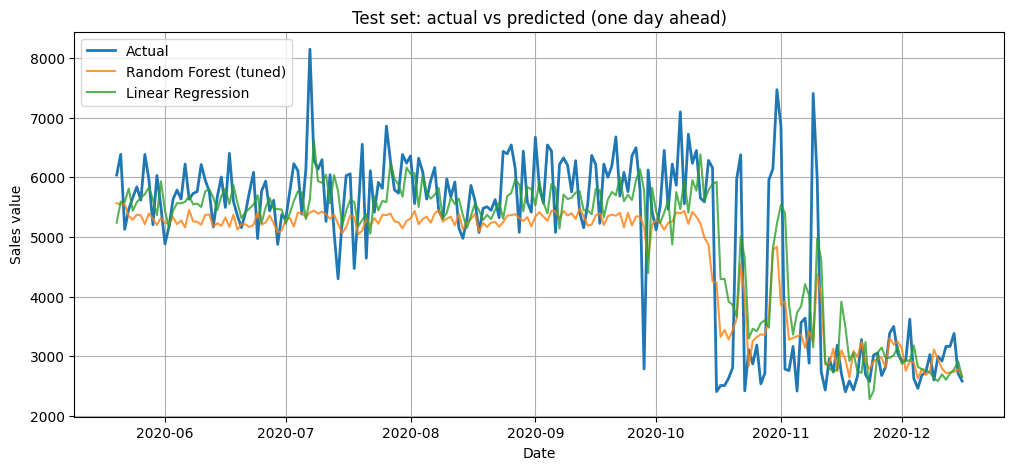

In [15]:
fig, ax = plt.subplots()
ax.plot(y_test.index, y_test.values, label="Actual", lw=2)
ax.plot(y_test.index, one_step_preds["Random Forest (tuned)"], label="Random Forest (tuned)", alpha=0.8)
ax.plot(y_test.index, one_step_preds["Linear Regression"], label="Linear Regression", alpha=0.8)
ax.set_title("Test set: actual vs predicted (one day ahead)")
ax.set_xlabel("Date"); ax.set_ylabel("Sales value"); ax.legend(); plt.show()

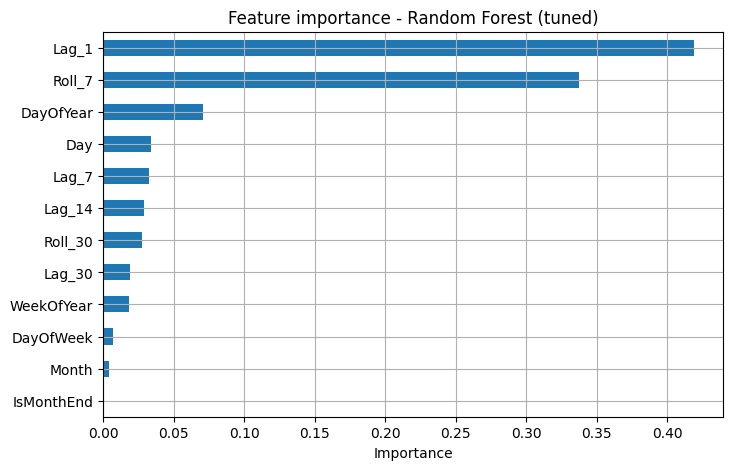

In [16]:
imp = pd.Series(rf_tuned.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", figsize=(8, 5), title="Feature importance - Random Forest (tuned)")
plt.xlabel("Importance"); plt.show()

## 8. Step B - realistic 30-day-ahead backtest

Step A is optimistic: the real forecast has no actual yesterday to look at after the first day. Each predicted day feeds the next (**recursive forecasting**), so errors compound.

To measure real 30-day accuracy, the models are refitted at **four different cut-off dates** near the end of the data. Each one forecasts the following 30 days blind, and the errors are averaged. This includes three simple baselines (last value, same as last week, and same day last year) and the classical time-series models (Holt-Winters and SARIMA) alongside the ML models. The last-year baseline matters because sales follow a strong yearly cycle.

In [17]:
def recursive_forecast(model, hist, horizon):
    """Predict day by day, feeding each prediction back in as history."""
    hist = hist.copy()
    idx = pd.date_range(hist.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    preds = []
    for date in idx:
        x = pd.DataFrame([row_features(hist, date)])[FEATURES]
        p = float(model.predict(x)[0])
        preds.append(p)
        hist.loc[date] = p
    return pd.Series(preds, index=idx)

def future_index(train, h):
    return pd.date_range(train.index[-1] + pd.Timedelta(days=1), periods=h, freq="D")

def fc_naive(train, h):
    return pd.Series(train.iloc[-1], index=future_index(train, h))

def fc_seasonal_naive(train, h):
    return pd.Series(np.resize(train.iloc[-7:].values, h), index=future_index(train, h))

def fc_last_year(train, h):
    # same day last year (364 days back = same weekday), smoothed with a 7-day centred mean to cut daily noise
    smooth = train.rolling(7, center=True, min_periods=1).mean()
    idx = future_index(train, h)
    return pd.Series([smooth.loc[d - pd.Timedelta(days=364)] for d in idx], index=idx)

def make_ml_forecaster(model):
    def f(train, h):
        d = make_features(train).dropna()
        m = clone(model).fit(d[FEATURES], d["Value"])
        return recursive_forecast(m, train, h)
    return f

def fc_holt_winters(train, h):
    fit = ExponentialSmoothing(train.asfreq("D"), trend="add", damped_trend=True,
                               seasonal="add", seasonal_periods=7).fit()
    return pd.Series(np.asarray(fit.forecast(h)), index=future_index(train, h))

def fc_sarima(train, h):
    fit = SARIMAX(train.asfreq("D"), order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit(disp=False, maxiter=100)
    return pd.Series(np.asarray(fit.forecast(h)), index=future_index(train, h))

forecasters = {
    "Naive (last value)":          fc_naive,
    "Seasonal naive (last week)":  fc_seasonal_naive,
    "Last year (7-day smoothed)":  fc_last_year,
    "Linear Regression":           make_ml_forecaster(LinearRegression()),
    "Random Forest (tuned)":       make_ml_forecaster(RandomForestRegressor(**best_rf_params, random_state=42)),
}
if HAS_SM:
    forecasters["Holt-Winters"] = fc_holt_winters
    forecasters["SARIMA"]       = fc_sarima
print("Models in the backtest:", list(forecasters))

Models in the backtest: ['Naive (last value)', 'Seasonal naive (last week)', 'Last year (7-day smoothed)', 'Linear Regression', 'Random Forest (tuned)', 'Holt-Winters', 'SARIMA']


In [18]:
N_FOLDS = 4
cutoffs = [len(sales) - HORIZON * k for k in range(N_FOLDS, 0, -1)]   # four consecutive 30-day windows

fold_scores = {name: [] for name in forecasters}
backtest_errors = {name: [] for name in forecasters}   # per fold: actual - predicted, used later for the uncertainty band
last_fold_preds = {}

for i, cut in enumerate(cutoffs):
    train_bt = sales.iloc[:cut]
    actual = sales.iloc[cut:cut + HORIZON]
    for name, fc in forecasters.items():
        pred = fc(train_bt, HORIZON)
        fold_scores[name].append(metrics(actual.values, pred.values))
        backtest_errors[name].append(actual.values - pred.values)
        if i == len(cutoffs) - 1:
            last_fold_preds[name] = pred
    print(f"fold {i+1}/{N_FOLDS} done  (forecast window: {actual.index[0].date()} to {actual.index[-1].date()})")

backtest_table = pd.DataFrame({name: pd.DataFrame(s).mean() for name, s in fold_scores.items()}).T
backtest_table = backtest_table.round(3).sort_values("RMSE")
backtest_table

fold 1/4 done  (forecast window: 2020-08-19 to 2020-09-17)
fold 2/4 done  (forecast window: 2020-09-18 to 2020-10-17)
fold 3/4 done  (forecast window: 2020-10-18 to 2020-11-16)
fold 4/4 done  (forecast window: 2020-11-17 to 2020-12-16)


,MAE,RMSE,MAPE %
Random Forest (tuned),684.502,949.711,15.827
Last year (7-day smoothed),742.268,963.240,15.725
Holt-Winters,862.317,1027.057,24.114
Linear Regression,949.048,1086.217,24.578
SARIMA,936.183,1102.072,27.561
Naive (last value),856.953,1166.797,17.358
Seasonal naive (last week),1141.537,1515.325,33.212


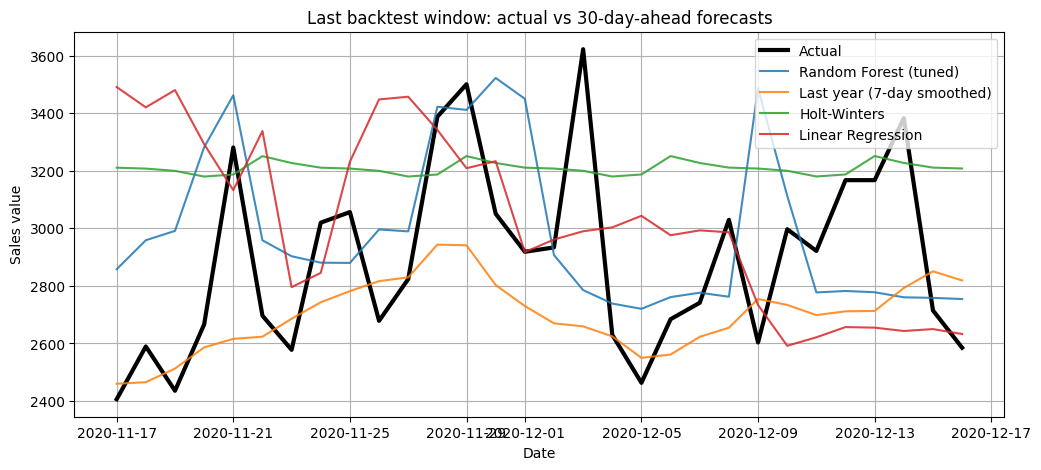

In [19]:
last_actual = sales.iloc[-HORIZON:]
fig, ax = plt.subplots()
ax.plot(last_actual.index, last_actual.values, color="black", lw=3, label="Actual")
for name in backtest_table.index[:4]:            # the four best models
    ax.plot(last_fold_preds[name].index, last_fold_preds[name].values, label=name, alpha=0.85)
ax.set_title("Last backtest window: actual vs 30-day-ahead forecasts")
ax.set_xlabel("Date"); ax.set_ylabel("Sales value"); ax.legend(); plt.show()

## 9. Choose the best model and forecast the next 30 days
The winner is the model with the lowest average 30-day-ahead RMSE in the backtest. It is refitted on **all** the data. The uncertainty band comes from that model's own errors in the most recent backtest window (5th to 95th percentile), which is the same season as the forecast. It is only an approximation: it rests on 30 error values.

In [20]:
best_name = backtest_table.index[0]
print("Best model:", best_name)

final_forecast = forecasters[best_name](sales, HORIZON)

# Band from the most recent backtest window: it is the same season as the forecast (mid-Nov to mid-Dec vs
# mid-Dec to mid-Jan). Errors pooled over all folds are inflated by the Oct->Nov switch to the low-sales season.
err = backtest_errors[best_name][-1]
lo_q, hi_q = np.percentile(err, [5, 95])
forecast_df = pd.DataFrame({
    "Date": final_forecast.index,
    "Predicted_Value": final_forecast.values,
    "Lower_90": np.maximum(final_forecast.values + lo_q, 0),
    "Upper_90": final_forecast.values + hi_q,
})
forecast_df.head(10)

Best model: Random Forest (tuned)


,Date,Predicted_Value,Lower_90,Upper_90
0,2020-12-17,2700.697954,2111.822324,3218.674805
1,2020-12-18,2762.721464,2173.845833,3280.698314
2,2020-12-19,2872.476971,2283.601340,3390.453821
3,2020-12-20,2917.872912,2328.997282,3435.849763
4,2020-12-21,2907.415680,2318.540050,3425.392531
5,2020-12-22,2960.242017,2371.366387,3478.218868
6,2020-12-23,2939.127767,2350.252137,3457.104618
7,2020-12-24,2984.181004,2395.305373,3502.157854
8,2020-12-25,2974.471485,2385.595855,3492.448336
9,2020-12-26,2985.833772,2396.958141,3503.810622


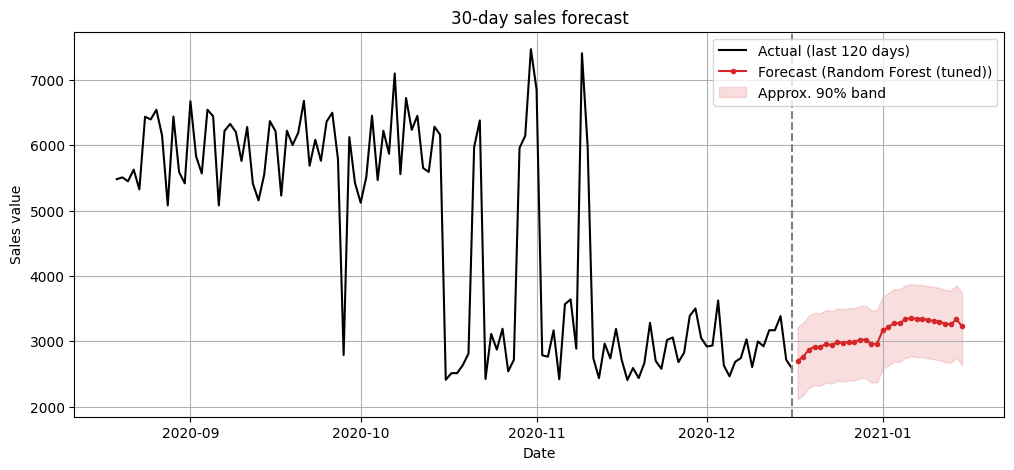

In [21]:
recent = sales.iloc[-120:]
fig, ax = plt.subplots()
ax.plot(recent.index, recent.values, label="Actual (last 120 days)", color="black")
ax.plot(forecast_df["Date"], forecast_df["Predicted_Value"], color="tab:red", marker="o", ms=3, label=f"Forecast ({best_name})")
ax.fill_between(forecast_df["Date"], forecast_df["Lower_90"], forecast_df["Upper_90"],
                color="tab:red", alpha=0.15, label="Approx. 90% band")
ax.axvline(sales.index[-1], color="grey", ls="--")
ax.set_title("30-day sales forecast"); ax.set_xlabel("Date"); ax.set_ylabel("Sales value")
ax.legend(); plt.show()

In [22]:
forecast_df.to_csv("30_Day_Sales_Forecast.csv", index=False)
print("Saved 30_Day_Sales_Forecast.csv")

try:
    from google.colab import files
    files.download("30_Day_Sales_Forecast.csv")
except ImportError:
    pass

Saved 30_Day_Sales_Forecast.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Results summary

In [23]:
best_row = backtest_table.loc[best_name]

baselines = ["Naive (last value)", "Seasonal naive (last week)", "Last year (7-day smoothed)"]

base_name = backtest_table.loc[baselines].sort_values("RMSE").index[0]

sn_row = backtest_table.loc[base_name]

peak = forecast_df.loc[forecast_df["Predicted_Value"].idxmax()]

print(f"Data           : {sales.index.min().date()} to {sales.index.max().date()} ({len(sales)} days, 1 product, 1 store)")

print(f"Best model     : {best_name}")

print(f"30-day backtest: MAE {best_row['MAE']:.0f} | RMSE {best_row['RMSE']:.0f} | MAPE {best_row['MAPE %']:.1f}%")

print(f"Best baseline  ({base_name}): MAE {sn_row['MAE']:.0f} | RMSE {sn_row['RMSE']:.0f} | MAPE {sn_row['MAPE %']:.1f}%")

mae_improvement = (1 - best_row["MAE"] / sn_row["MAE"]) * 100
rmse_improvement = (1 - best_row["RMSE"] / sn_row["RMSE"]) * 100

print(f"MAE improvement vs best baseline: {mae_improvement:.1f}% lower")
print(f"RMSE improvement vs best baseline: {rmse_improvement:.1f}% lower")
print(f"MAPE comparison: {best_row['MAPE %']:.1f}% vs {sn_row['MAPE %']:.1f}% for the baseline")

print(f"Forecast       : {forecast_df['Date'].min().date()} to {forecast_df['Date'].max().date()}, "
      f"average {forecast_df['Predicted_Value'].mean():.0f}")

print(f"Forecast peak  : {peak['Predicted_Value']:.0f} on {peak['Date'].date()}")

Data           : 2018-01-01 to 2020-12-16 (1081 days, 1 product, 1 store)
Best model     : Random Forest (tuned)
30-day backtest: MAE 685 | RMSE 950 | MAPE 15.8%
Best baseline  (Last year (7-day smoothed)): MAE 742 | RMSE 963 | MAPE 15.7%
MAE improvement vs best baseline: 7.8% lower
RMSE improvement vs best baseline: 1.4% lower
MAPE comparison: 15.8% vs 15.7% for the baseline
Forecast       : 2020-12-17 to 2021-01-15, average 3110
Forecast peak  : 3357 on 2021-01-06


## Conclusions and limitations

- **Method:** the data was cleaned (dates repaired, gap days filled), explored, turned into calendar/lag/rolling features, and used to compare naive baselines, Linear Regression, a tuned Random Forest, and (when statsmodels is available) Holt-Winters and SARIMA.
- **Evaluation:** models were compared on a chronological split (one day ahead) and on a four-fold, 30-day-ahead backtest. The backtest is the honest measure because the final forecast is also 30 days ahead.
- **Error compounding:** ML forecasts feed their own predictions back in, so error grows with the horizon. The shaded band reflects the observed backtest error, not a theoretical guarantee.
- **Scope:** one product and one store, so results do not transfer to other items. Only calendar and past-sales information is used; promotions, prices, holidays and weather are not in the data, which limits the achievable accuracy.
- **Yearly seasonality:** sales sit at a low level from November to April and a much higher level from May to October, repeating every year with modest growth. The switches around May and November are the hardest periods to forecast, and with only three years of data each switch has been seen just two or three times.
- **Simple baselines are strong:** compare the best model against the best baseline in the results table. If the gap is small, say so; it means most of the predictable signal is the yearly pattern.
- **Next steps:** add holiday/promotion flags, train per product/store when more data is available, and try Prophet or gradient boosting.